In [1]:
# Install any missing libraries
!pip install -q opencv-python-headless

In [3]:
# Imports and GPU/CPU setup
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

# GPU check and mixed precision (only if GPU available)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU detected. Enabling mixed precision for speed.")
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
else:
    print("⚠️ No GPU detected. Running on CPU (mixed precision disabled).")
    tf.keras.mixed_precision.set_global_policy('float32')

TensorFlow version: 2.19.0
✅ GPU detected. Enabling mixed precision for speed.


In [4]:
#Set BASE_DIR (point to the dataset on Kaggle)
BASE_DIR = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
print("BASE_DIR exists?", os.path.exists(BASE_DIR))
print("Contents:", os.listdir(BASE_DIR)[:10])

BASE_DIR exists? True
Contents: ['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [5]:
# Load CSV files
train_df = pd.read_csv(os.path.join(BASE_DIR, 'Train.csv'))
test_df = pd.read_csv(os.path.join(BASE_DIR, 'Test.csv'))
meta_df = pd.read_csv(os.path.join(BASE_DIR, 'Meta.csv'))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Meta shape:", meta_df.shape)

# Show first rows
print("\nTraining sample:")
print(train_df.head())

Train shape: (39209, 8)
Test shape: (12630, 8)
Meta shape: (43, 5)

Training sample:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


In [6]:
#Stratified split (80% train, 20% validation)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in splitter.split(train_df, train_df['ClassId']):
    train_sub = train_df.iloc[train_idx].reset_index(drop=True)
    val_sub = train_df.iloc[val_idx].reset_index(drop=True)

print(f"Training set size: {len(train_sub)}")
print(f"Validation set size: {len(val_sub)}")

Training set size: 31367
Validation set size: 7842


In [7]:
#Fix image paths – convert folder names and extensions
def fix_paths(df, base_dir, is_train=True):
    new_paths = []
    for _, row in df.iterrows():
        path = row['Path']
        # Split path
        parts = path.split('/')
        if is_train and len(parts) >= 3 and parts[0] == 'Train':
            # Convert class folder from e.g., '00000' to '0'
            class_id_int = int(parts[1])
            parts[1] = str(class_id_int)
            # Rejoin
            new_path = '/'.join(parts)
        else:
            new_path = path
        # Replace .ppm with .png (actual files are .png)
        new_path = new_path.replace('.ppm', '.png')
        # Remove any double slashes
        new_path = new_path.replace('//', '/')
        new_paths.append(new_path)
    df['Path'] = new_paths
    return df

train_sub = fix_paths(train_sub, BASE_DIR, is_train=True)
val_sub = fix_paths(val_sub, BASE_DIR, is_train=True)
test_df = fix_paths(test_df, BASE_DIR, is_train=False)   # test set paths: 'Test/00000.png'

# Verify the fix
sample_path = os.path.join(BASE_DIR, train_sub.iloc[0]['Path'])
print("Sample train image exists?", os.path.exists(sample_path))
sample_test = os.path.join(BASE_DIR, test_df.iloc[0]['Path'])
print("Sample test image exists?", os.path.exists(sample_test))

Sample train image exists? True
Sample test image exists? True


In [8]:
#Convert ClassId to string (required for categorical generator)
train_sub['ClassId'] = train_sub['ClassId'].astype(str)
val_sub['ClassId'] = val_sub['ClassId'].astype(str)
test_df['ClassId'] = test_df['ClassId'].astype(str)

In [9]:
# Create data generators (augmentation + rescaling)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_sub,
    directory=BASE_DIR,
    x_col='Path',
    y_col='ClassId',
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_sub,
    directory=BASE_DIR,
    x_col='Path',
    y_col='ClassId',
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=BASE_DIR,
    x_col='Path',
    y_col='ClassId',
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Train batches:", len(train_generator))
print("Val batches:", len(val_generator))
print("Test batches:", len(test_generator))

Found 31367 validated image filenames belonging to 43 classes.
Found 7842 validated image filenames belonging to 43 classes.
Found 12630 validated image filenames belonging to 43 classes.
Train batches: 981
Val batches: 246
Test batches: 395


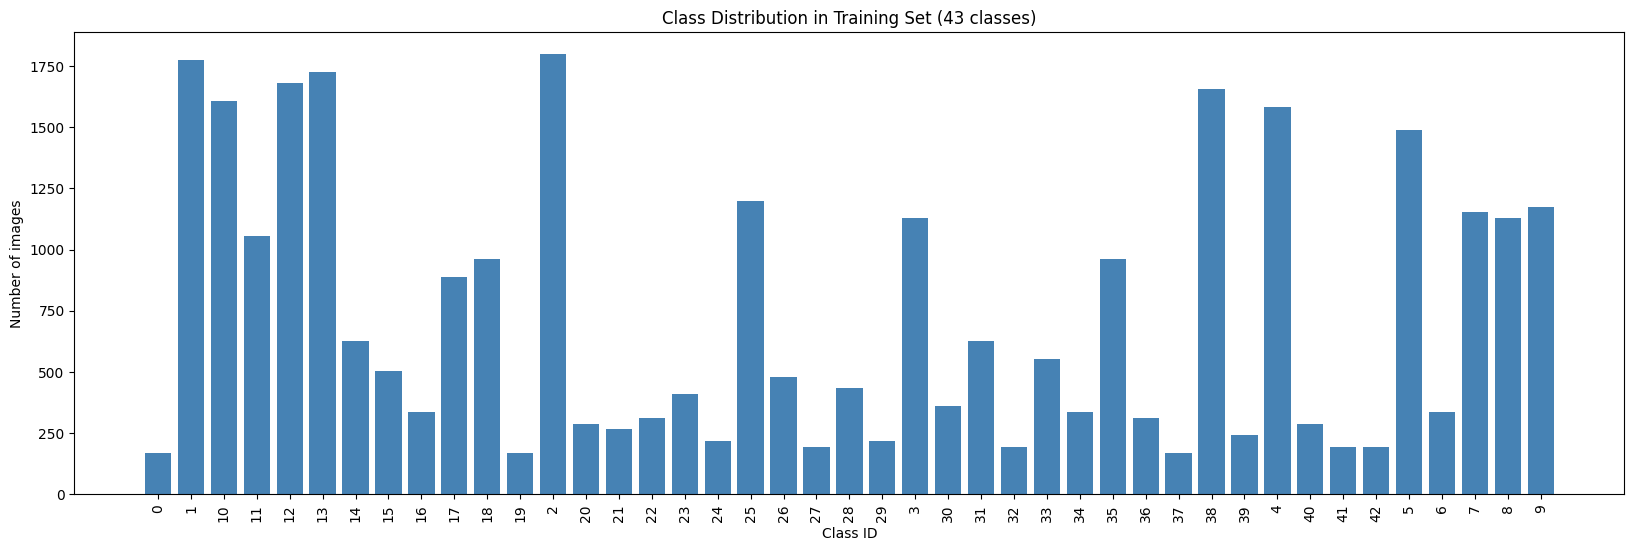

Min images/class: 168
Max images/class: 1800
Mean images/class: 729.5


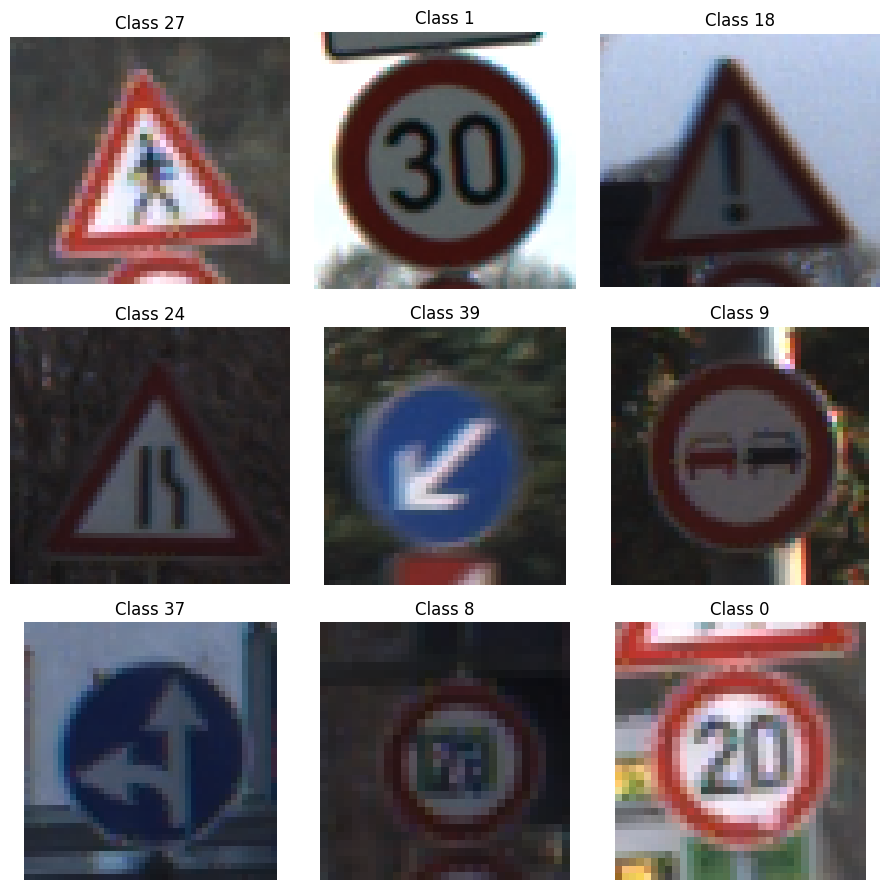

In [10]:
#Exploratory Data Analysis (EDA) – class distribution + sample images
class_counts = train_sub['ClassId'].value_counts().sort_index().astype(int)
plt.figure(figsize=(20,6))
plt.bar(class_counts.index, class_counts.values, color='steelblue')
plt.xlabel('Class ID')
plt.ylabel('Number of images')
plt.title('Class Distribution in Training Set (43 classes)')
plt.xticks(range(43), rotation=90)
plt.show()

print(f"Min images/class: {class_counts.min()}")
print(f"Max images/class: {class_counts.max()}")
print(f"Mean images/class: {class_counts.mean():.1f}")

# Display sample images
sample_classes = np.random.choice(class_counts.index, 9, replace=False)
fig, axes = plt.subplots(3,3, figsize=(9,9))
for ax, cls in zip(axes.flat, sample_classes):
    path = train_sub[train_sub['ClassId'] == str(cls)].iloc[0]['Path']
    img = cv2.imread(os.path.join(BASE_DIR, path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Class {cls}")
    ax.axis('off')
plt.tight_layout()
plt.show()

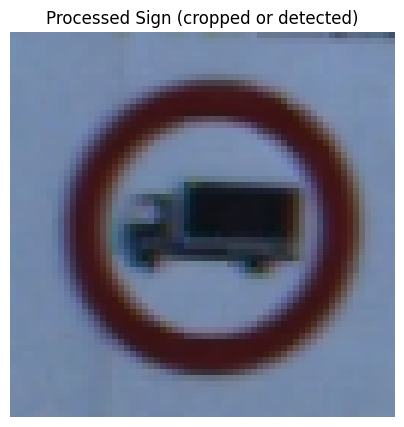

Detection/cropping succeeded.


In [13]:
#Sign Detection & Cropping (HSV + contours)
def detect_and_crop_sign(image_path, min_area=500):
    """
    Detect and crop a traffic sign from a full road scene.
    If no sign is found, assume the entire image is the sign (cropped input).
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    
    # Convert to HSV for red colour segmentation
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Red colour ranges (two ranges because red wraps around HSV)
    lower1 = np.array([0, 70, 50])
    upper1 = np.array([10, 255, 255])
    lower2 = np.array([170, 70, 50])
    upper2 = np.array([180, 255, 255])
    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)
    mask = cv2.bitwise_or(mask1, mask2)
    
    # Clean mask
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Largest contour (assumed to be the sign)
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        area = w * h
        aspect = w / h
        # Filter by size and aspect ratio (roughly square)
        if area >= min_area and 0.5 < aspect < 1.5:
            cropped = img[y:y+h, x:x+w]
            cropped = cv2.resize(cropped, (64,64))
            return cropped, (x, y, w, h)
    
    # If no sign found, assume the whole image is a cropped sign
    cropped = cv2.resize(img, (64,64))
    return cropped, None

# Test on the first test image (cropped sign)
test_img_path = os.path.join(BASE_DIR, test_df.iloc[0]['Path'])
cropped, bbox = detect_and_crop_sign(test_img_path)

if cropped is not None:
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    plt.title("Processed Sign (cropped or detected)")
    plt.axis('off')
    plt.show()
    print("Detection/cropping succeeded.")
else:
    print("Failed to process image.")
    
   

In [19]:
# Custom CNN – 3 Configurations (Memory-Efficient & Error-Resilient)

def build_custom_cnn(config='A', input_shape=(64,64,3), num_classes=43):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))
    if config in ['B', 'C']:
        model.add(layers.Conv2D(64, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))
    if config == 'C':
        model.add(layers.Conv2D(128, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    if config == 'A':
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.Dropout(0.3))
    elif config == 'B':
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dropout(0.4))
    else:
        model.add(layers.Dense(256, activation='relu'))
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Use smaller batch size to avoid OOM
batch_size = 16  # reduced from 32
print(f"Using batch size: {batch_size}")

# Recreate generators with smaller batch size
train_generator_small = train_datagen.flow_from_dataframe(
    dataframe=train_sub,
    directory=BASE_DIR,
    x_col='Path',
    y_col='ClassId',
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator_small = val_test_datagen.flow_from_dataframe(
    dataframe=val_sub,
    directory=BASE_DIR,
    x_col='Path',
    y_col='ClassId',
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical'
)

cnn_results = {}
for cfg in ['A', 'B', 'C']:
    print(f"\n{'='*40}")
    print(f"Training Custom CNN Configuration {cfg}")
    print('='*40)
    model = build_custom_cnn(cfg)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('best_cnn_A.keras', save_best_only=True, monitor='val_accuracy', mode='max')
]
    
    start = time.time()
    history = model.fit(
        train_generator_small,
        validation_data=val_generator_small,
        epochs=12,
        callbacks=callbacks,
        verbose=1,
        # Add steps per epoch to avoid memory buildup (optional)
        steps_per_epoch=len(train_generator_small),
        validation_steps=len(val_generator_small)
    )
    train_min = (time.time() - start) / 60
    best_acc = max(history.history['val_accuracy'])
    cnn_results[cfg] = {
        'model': model,
        'val_acc': best_acc,
        'train_time': train_min,
        'history': history
    }
    print(f"Config {cfg} -> Val acc: {best_acc:.4f}, Time: {train_min:.2f} min")

# After training, reset generators to original batch size if needed (for later cells)
# But we can keep using the smaller generator
train_generator = train_generator_small
val_generator = val_generator_small

Using batch size: 16
Found 31367 validated image filenames belonging to 43 classes.
Found 7842 validated image filenames belonging to 43 classes.

Training Custom CNN Configuration A
Epoch 1/12
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - accuracy: 0.2163 - loss: 2.8730 - val_accuracy: 0.5488 - val_loss: 1.3860
Epoch 2/12
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 87s 44ms/step - accuracy: 0.4302 - loss: 1.7821 - val_accuracy: 0.6654 - val_loss: 1.0661
Epoch 3/12
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - accuracy: 0.4916 - loss: 1.5749 - val_accuracy: 0.6818 - val_loss: 0.9922
Epoch 4/12
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 85s 43ms/step - accuracy: 0.5135 - loss: 1.5018 - val_accuracy: 0.7340 - val_loss: 0.8301
Epoch 5/12
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.5345 - loss: 1.4300 - val_accuracy: 0.7290 - val_loss: 0.7977
Epoch 6/12
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.5454 - loss: 1.3921 - val_accuracy: 0.7568 - val_loss: 0.7236
Epoch 7/12
1961/1961 ━━━━

In [21]:
#Transfer Learning – MobileNetV2 & ResNet50
def build_transfer_model(base_name, input_shape=(64,64,3), num_classes=43):
    if base_name == 'MobileNetV2':
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

transfer_results = {}
for name in ['MobileNetV2', 'ResNet50']:
    print(f"\n=== Training {name} ===")
    model = build_transfer_model(name)
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    ModelCheckpoint('best_cnn_A.keras', save_best_only=True, 
                    monitor='val_accuracy', mode='max')

    history = model.fit(train_generator, validation_data=val_generator,
                        epochs=15, callbacks=callbacks, verbose=1)
    train_min = (time.time() - start) / 60
    best_acc = max(history.history['val_accuracy'])
    transfer_results[name] = {'model': model, 'val_acc': best_acc, 'train_time': train_min}
    print(f"{name} -> Val acc: {best_acc:.4f}, Time: {train_min:.2f} min")


=== Training MobileNetV2 ===
Epoch 1/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 128s 57ms/step - accuracy: 0.2054 - loss: 3.1076 - val_accuracy: 0.4603 - val_loss: 1.8607
Epoch 2/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.4328 - loss: 1.9315 - val_accuracy: 0.5321 - val_loss: 1.5322
Epoch 3/15
1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5001 - loss: 1.6241

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 86s 44ms/step - accuracy: 0.5002 - loss: 1.6241 - val_accuracy: 0.5723 - val_loss: 1.3793
Epoch 4/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5440 - loss: 1.4761

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - accuracy: 0.5440 - loss: 1.4761 - val_accuracy: 0.5963 - val_loss: 1.2812
Epoch 5/15
1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5657 - loss: 1.3624

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - accuracy: 0.5657 - loss: 1.3623 - val_accuracy: 0.6150 - val_loss: 1.2001
Epoch 6/15
1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5899 - loss: 1.2788

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.5899 - loss: 1.2788 - val_accuracy: 0.6227 - val_loss: 1.1662
Epoch 7/15
1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6039 - loss: 1.2273

...

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 87s 45ms/step - accuracy: 0.6474 - loss: 1.0737 - val_accuracy: 0.6704 - val_loss: 1.0126
Epoch 12/15
1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6565 - loss: 1.0334

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 86s 44ms/step - accuracy: 0.6565 - loss: 1.0334 - val_accuracy: 0.6798 - val_loss: 0.9798
Epoch 13/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6649 - loss: 1.0210

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.6649 - loss: 1.0210 - val_accuracy: 0.6830 - val_loss: 0.9684
Epoch 14/15
1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6705 - loss: 1.0079

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.6705 - loss: 1.0079 - val_accuracy: 0.6959 - val_loss: 0.9368
Epoch 15/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6733 - loss: 0.9800

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 85s 43ms/step - accuracy: 0.6733 - loss: 0.9800 - val_accuracy: 0.6946 - val_loss: 0.9302
MobileNetV2 -> Val acc: 0.6959, Time: 27.65 min

=== Training ResNet50 ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.0553 - loss: 3.5900 - val_accuracy: 0.1058 - val_loss: 3.4022
Epoch 2/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.0883 - loss: 3.4309 - val_accuracy: 0.1251 - val_loss: 3.3064
Epoch 3/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.1108 - loss: 3.3490 - val_accuracy: 0.1562 - val_loss: 3.2165
Epoch 4/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.1319 - loss: 3.2733 - val_accuracy: 0.1711 - val_loss: 3.1395
Epoch 5/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.1439 - loss: 3.2045 - val_accuracy: 0.1853 - val_loss: 3.0676
Epoch 6/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.1541 - loss: 3.1593 - 


=== Speed vs. Accuracy Trade-off ===
      Model  Val Acc %  Inference (ms)  Size (MB)  Train Time (min)
      CNN_A  80.374902        2.229306  24.549975         16.875503
      CNN_B  96.799284        2.381206  31.149941         16.882636
      CNN_C  99.477172        9.282279  24.549975         16.505834
MobileNetV2  69.586837      258.851742  12.416615         27.650059
   ResNet50  27.850038       69.984342  95.725652         48.957690


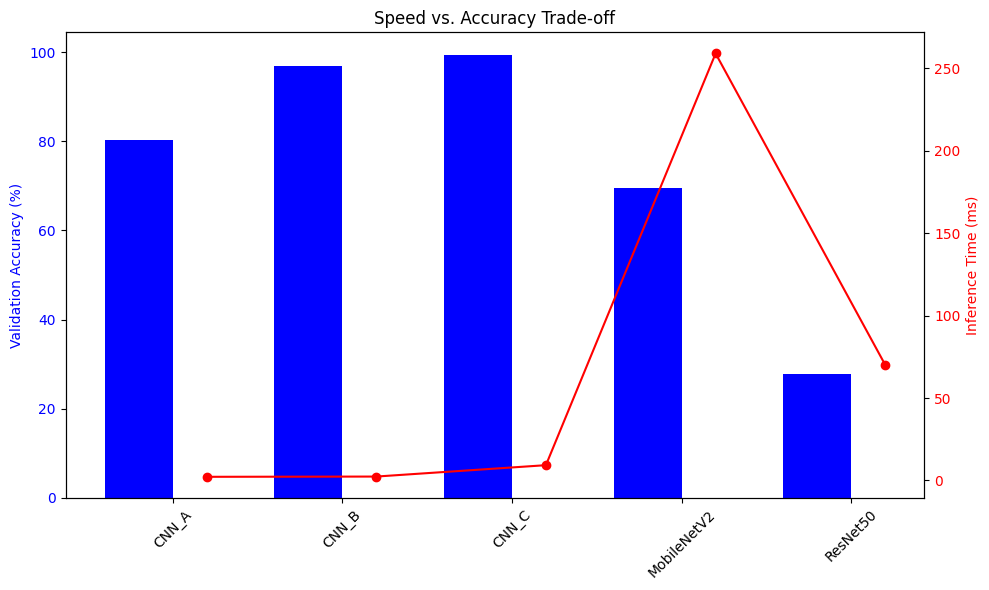

In [24]:
# Speed vs. Accuracy Analysis (robust – saves model if missing)

def measure_inference_time(model, generator, num_samples=100):
    sample_imgs, _ = next(generator)
    total_time = 0.0
    batches = num_samples // generator.batch_size
    for _ in range(batches):
        start = time.time()
        _ = model.predict(sample_imgs, verbose=0)
        total_time += time.time() - start
    avg_time_ms = (total_time / batches) * 1000 / generator.batch_size
    return avg_time_ms

def model_size_mb(model, filename):
    """Save model to file (if needed) and return size in MB."""
    if not os.path.exists(filename):
        model.save(filename)
    return os.path.getsize(filename) / (1024 ** 2)

summary = []

# Custom CNN models
for cfg, data in cnn_results.items():
    model = data['model']
    inf = measure_inference_time(model, test_generator)
    # Use a consistent filename; if missing, save it now
    filename = f'best_cnn_{cfg}.keras'
    sz = model_size_mb(model, filename)
    summary.append({
        'Model': f'CNN_{cfg}',
        'Val Acc %': data['val_acc'] * 100,
        'Inference (ms)': inf,
        'Size (MB)': sz,
        'Train Time (min)': data['train_time']
    })

# Transfer learning models
for name, data in transfer_results.items():
    model = data['model']
    inf = measure_inference_time(model, test_generator)
    filename = f'best_{name}.keras'
    sz = model_size_mb(model, filename)
    summary.append({
        'Model': name,
        'Val Acc %': data['val_acc'] * 100,
        'Inference (ms)': inf,
        'Size (MB)': sz,
        'Train Time (min)': data['train_time']
    })

df_summary = pd.DataFrame(summary)
print("\n=== Speed vs. Accuracy Trade-off ===")
print(df_summary.to_string(index=False))

# Dual-axis plot
fig, ax1 = plt.subplots(figsize=(10,6))
x = np.arange(len(df_summary))
ax1.bar(x - 0.2, df_summary['Val Acc %'], width=0.4, color='blue', label='Accuracy')
ax1.set_ylabel('Validation Accuracy (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(df_summary['Model'], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x + 0.2, df_summary['Inference (ms)'], 'ro-', label='Inference Time')
ax2.set_ylabel('Inference Time (ms)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Speed vs. Accuracy Trade-off')
fig.tight_layout()
plt.show()


Best model: CNN_C
395/395 ━━━━━━━━━━━━━━━━━━━━ 73s 185ms/step - accuracy: 0.9641 - loss: 0.1829
Test Accuracy: 0.9644
Test Loss: 0.1836


395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9833    0.9916        60
           1     0.9958    0.9861    0.9909       720
           2     1.0000    0.9818    0.9908       660
           3     0.9919    0.8786    0.9318       420
           4     0.9597    0.9652    0.9624       690
           5     0.9836    0.9986    0.9910       720
           6     1.0000    1.0000    1.0000       270
           7     0.9721    0.9952    0.9835       210
           8     1.0000    1.0000    1.0000       150
           9     1.0000    0.8889    0.9412       360
          10     1.0000    0.8923    0.9431       390
          11     0.8696    1.0000    0.9302        60
          12     0.9651    0.9960    0.9803       750
          13     0.7826    1.0000    0.8780        90
          14     0.7849    0.8111    0.7978        90
          15     0.9811    0.8667    0.9204       120
          16  

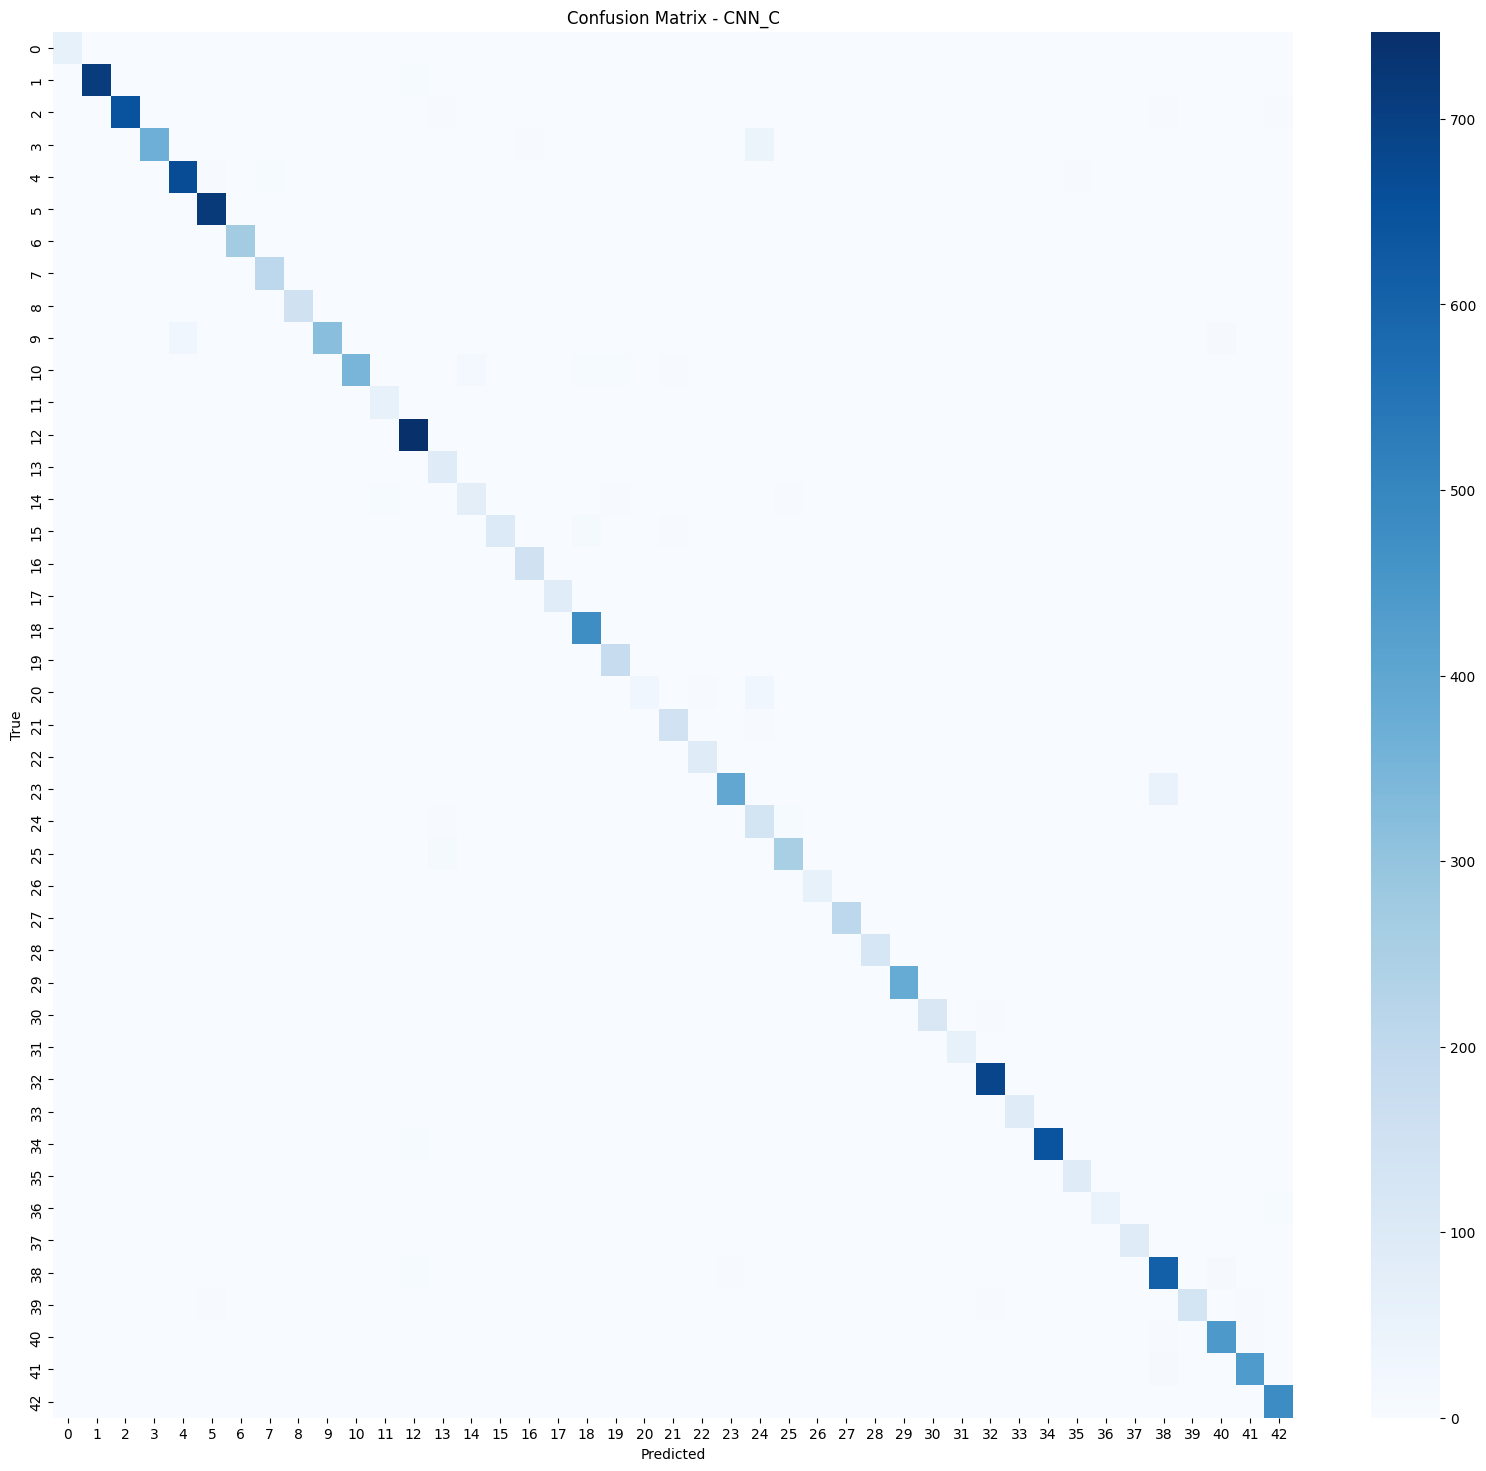

In [25]:
#Evaluate Best Model on Test Set
best_model_name = df_summary.loc[df_summary['Val Acc %'].idxmax(), 'Model']
if best_model_name.startswith('CNN'):
    best_model = cnn_results[best_model_name.split('_')[1]]['model']
else:
    best_model = transfer_results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_true = test_generator.classes
y_pred = np.argmax(best_model.predict(test_generator, verbose=1), axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20,18))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=range(43), yticklabels=range(43))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

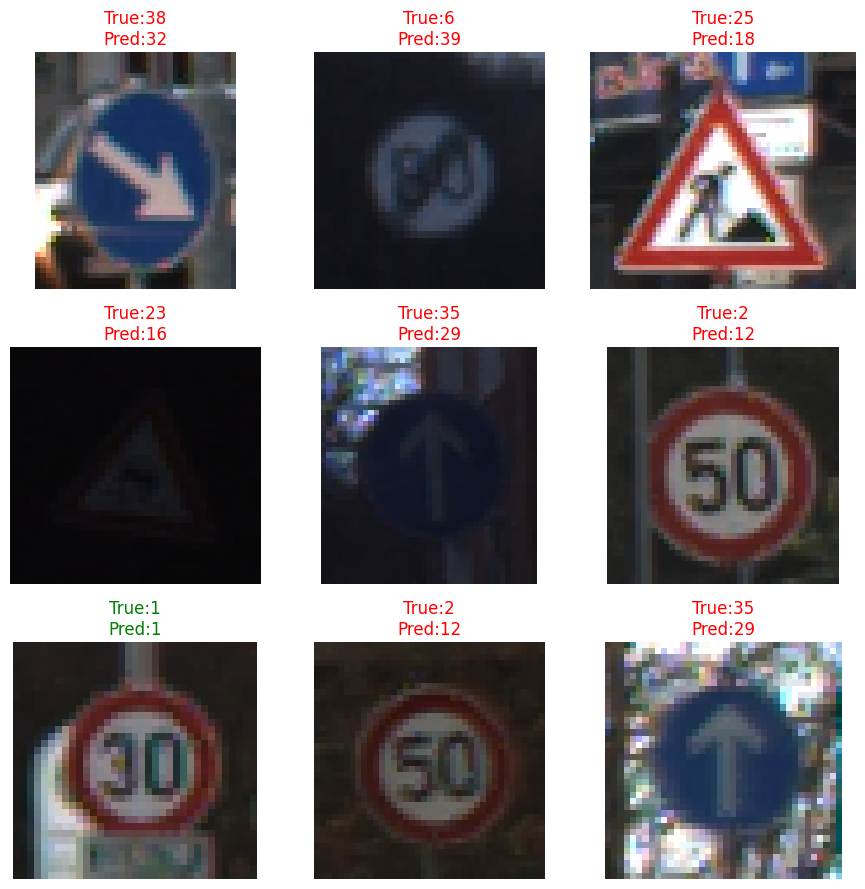

In [26]:
#Sample Predictions on Test Images
sample_indices = np.random.choice(len(test_df), 9, replace=False)
fig, axes = plt.subplots(3,3, figsize=(9,9))
for ax, idx in zip(axes.flat, sample_indices):
    path = os.path.join(BASE_DIR, test_df.iloc[idx]['Path'])
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    true_label = int(test_df.iloc[idx]['ClassId'])
    pred_label = y_pred[idx]
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(img)
    ax.set_title(f"True:{true_label}\nPred:{pred_label}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [27]:
#Save the Best Model for Deployment
best_model.save('best_traffic_sign_model.keras')
print("Model saved as 'best_traffic_sign_model.keras'")

Model saved as 'best_traffic_sign_model.keras'


In [28]:
#Download the model from Kaggle
from IPython.display import FileLink
print("Click the link below to download the model:")
FileLink('best_traffic_sign_model.keras')

Click the link below to download the model:


/kaggle/working/best_traffic_sign_model.keras